# Notebook — Teste do módulo `heights.py`

Este notebook testa o módulo:

```python
geodesy/heights.py
```

Serão testadas as funções:

- `geopotential_number`
- `dynamic_height`
- `orthometric_height_approx`
- `normal_height`
- `ellipsoidal_to_orthometric_height`
- `orthometric_to_ellipsoidal_height`
- `ellipsoidal_to_normal_height`
- `normal_to_ellipsoidal_height`
- `geoid_quasigeoid_separation`

Os exemplos simulam sistemas de alturas, conversão entre altura elipsoidal e ortométrica, altura normal e relação entre geoide e quasigeoide.


In [1]:
# ============================================================
# 0. CONFIGURAÇÃO INICIAL
# ============================================================

import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

current_dir = Path.cwd()

if (current_dir / "geodesy").exists():
    sys.path.insert(0, str(current_dir))
    print("Pasta geodesy encontrada no diretório atual.")
else:
    print("Atenção: a pasta geodesy não foi encontrada no diretório atual.")
    print("Coloque este notebook no mesmo diretório da pasta geodesy/.")

import geodesy
from geodesy import heights
from geodesy import geoid
from geodesy import normal_gravity

print("Versão do pacote geodesy:", geodesy.__version__)


Pasta geodesy encontrada no diretório atual.
Versão do pacote geodesy: 0.1.0


## 1. Número geopotencial


Potenciais WP:
[62636856. 62636756. 62636356. 62635856. 62634856. 62631856.]

Números geopotenciais C = W0 - WP:
[   0.  100.  500. 1000. 2000. 5000.]


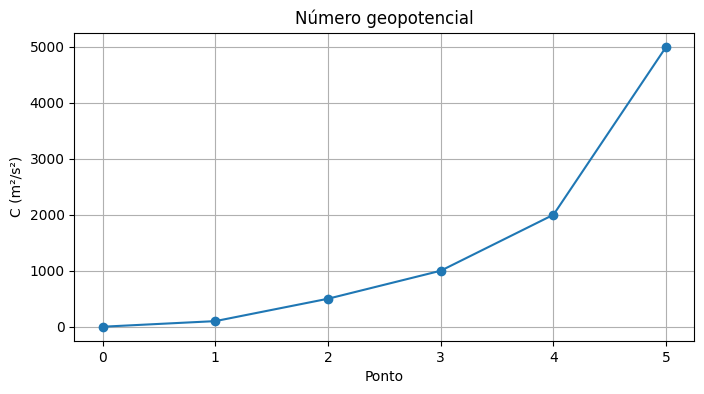

In [2]:
# ============================================================
# 1. NÚMERO GEOPOTENCIAL
# ============================================================

W0 = 62636856.0  # valor de referência fictício em m²/s²
WP = np.array([
    W0,
    W0 - 100,
    W0 - 500,
    W0 - 1000,
    W0 - 2000,
    W0 - 5000
], dtype=float)

C = heights.geopotential_number(W0, WP)

print("Potenciais WP:")
print(WP)

print("\nNúmeros geopotenciais C = W0 - WP:")
print(C)

plt.figure(figsize=(8, 4))
plt.plot(C, marker="o")
plt.xlabel("Ponto")
plt.ylabel("C (m²/s²)")
plt.title("Número geopotencial")
plt.grid(True)
plt.show()


## 2. Altura dinâmica


Altura dinâmica:
[  0.          10.19716213  50.98581065 101.9716213  203.9432426
 509.85810649]


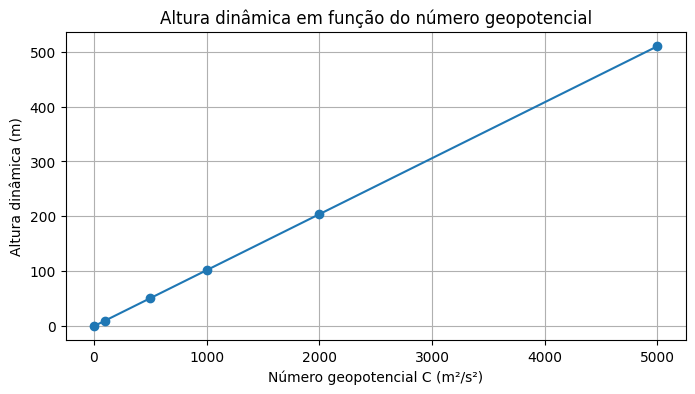

In [3]:
# ============================================================
# 2. ALTURA DINÂMICA
# ============================================================

H_dyn = heights.dynamic_height(C, gamma0=9.80665)

print("Altura dinâmica:")
print(H_dyn)

plt.figure(figsize=(8, 4))
plt.plot(C, H_dyn, marker="o")
plt.xlabel("Número geopotencial C (m²/s²)")
plt.ylabel("Altura dinâmica (m)")
plt.title("Altura dinâmica em função do número geopotencial")
plt.grid(True)
plt.show()


## 3. Altura ortométrica aproximada e altura normal


Altura ortométrica aproximada:
[  0.          10.19679821  50.98399103 101.96798205 203.93596411
 509.83991027]

Altura normal:
[  0.          10.19763007  50.98815035 101.97630071 203.95260142
 509.88150354]

Diferença H_ortho - H_norm:
[ 0.         -0.00083187 -0.00415933 -0.00831865 -0.01663731 -0.04159327]


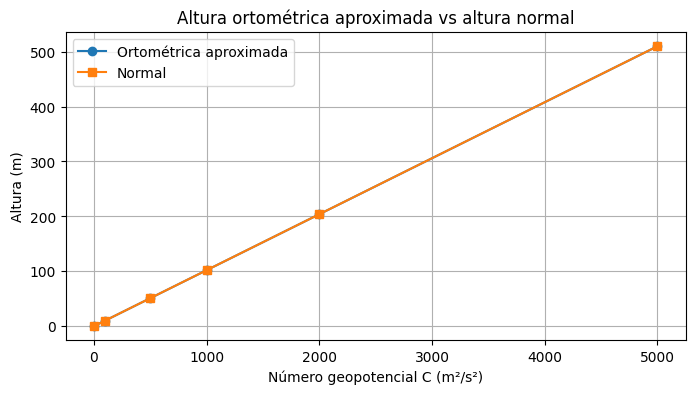

In [4]:
# ============================================================
# 3. ALTURA ORTOMÉTRICA E NORMAL
# ============================================================

mean_gravity = 9.8070
mean_normal_gravity = 9.8062

H_ortho = heights.orthometric_height_approx(C, mean_gravity=mean_gravity)
H_norm = heights.normal_height(C, mean_normal_gravity=mean_normal_gravity)

print("Altura ortométrica aproximada:")
print(H_ortho)

print("\nAltura normal:")
print(H_norm)

print("\nDiferença H_ortho - H_norm:")
print(H_ortho - H_norm)

plt.figure(figsize=(8, 4))
plt.plot(C, H_ortho, marker="o", label="Ortométrica aproximada")
plt.plot(C, H_norm, marker="s", label="Normal")
plt.xlabel("Número geopotencial C (m²/s²)")
plt.ylabel("Altura (m)")
plt.title("Altura ortométrica aproximada vs altura normal")
plt.legend()
plt.grid(True)
plt.show()


## 4. Conversão altura elipsoidal para ortométrica


Erro máximo no retorno h -> H -> h:
1.4210854715202004e-14


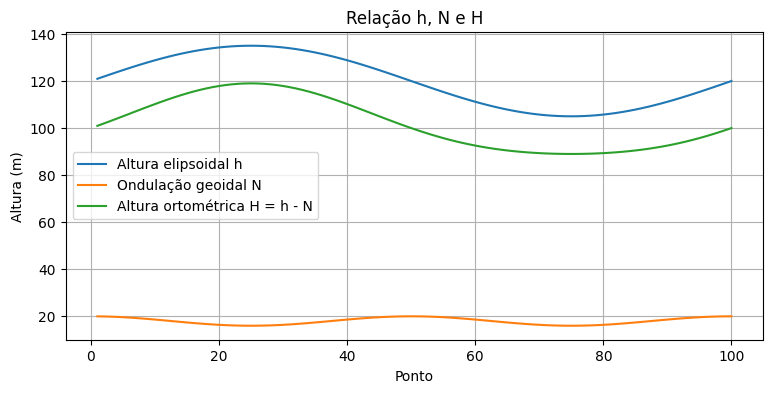

In [5]:
# ============================================================
# 4. h -> H USANDO GEOIDE N
# ============================================================

dias = np.arange(1, 101)

# Altura elipsoidal sintética
h = 120.0 + 15.0*np.sin(2*np.pi*dias/100)

# Ondulação geoidal sintética
N = 18.0 + 2.0*np.cos(2*np.pi*dias/50)

H = heights.ellipsoidal_to_orthometric_height(h, N)
h_back = heights.orthometric_to_ellipsoidal_height(H, N)

print("Erro máximo no retorno h -> H -> h:")
print(np.max(np.abs(h_back - h)))

plt.figure(figsize=(9, 4))
plt.plot(dias, h, label="Altura elipsoidal h")
plt.plot(dias, N, label="Ondulação geoidal N")
plt.plot(dias, H, label="Altura ortométrica H = h - N")
plt.xlabel("Ponto")
plt.ylabel("Altura (m)")
plt.title("Relação h, N e H")
plt.legend()
plt.grid(True)
plt.show()


## 5. Conversão altura elipsoidal para altura normal


Erro máximo no retorno h -> H_normal -> h:
1.4210854715202004e-14


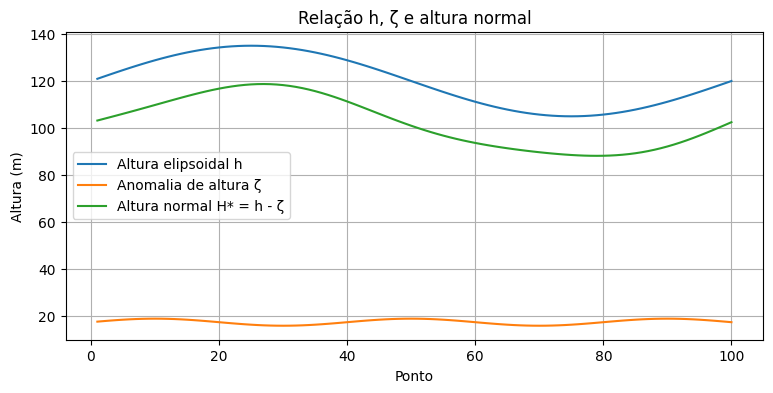

In [6]:
# ============================================================
# 5. h -> H_NORMAL USANDO ZETA
# ============================================================

zeta = 17.5 + 1.5*np.sin(2*np.pi*dias/40)

H_normal = heights.ellipsoidal_to_normal_height(h, zeta)
h_back_normal = heights.normal_to_ellipsoidal_height(H_normal, zeta)

print("Erro máximo no retorno h -> H_normal -> h:")
print(np.max(np.abs(h_back_normal - h)))

plt.figure(figsize=(9, 4))
plt.plot(dias, h, label="Altura elipsoidal h")
plt.plot(dias, zeta, label="Anomalia de altura ζ")
plt.plot(dias, H_normal, label="Altura normal H* = h - ζ")
plt.xlabel("Ponto")
plt.ylabel("Altura (m)")
plt.title("Relação h, ζ e altura normal")
plt.legend()
plt.grid(True)
plt.show()


## 6. Separação geoide-quasigeoide


Separação N - ζ:
Mínima: -1.2526393395673132
Máxima: 2.5
Média: 0.309406928957379


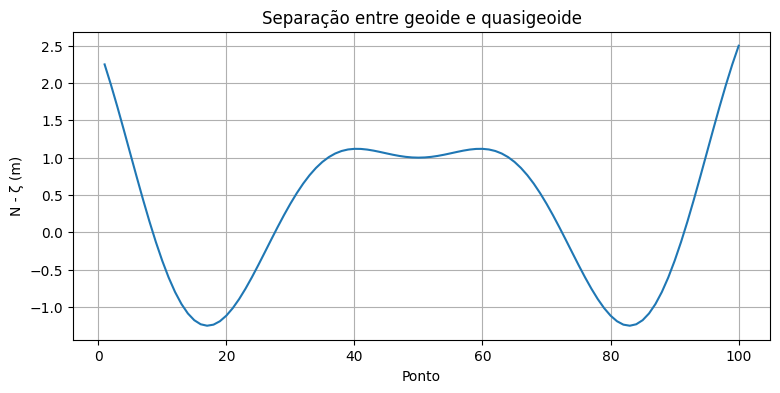

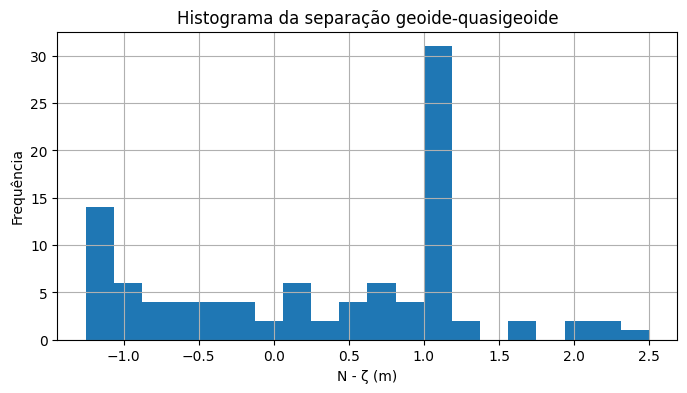

In [7]:
# ============================================================
# 6. SEPARAÇÃO GEOIDE-QUASIGEOIDE
# ============================================================

separation = heights.geoid_quasigeoid_separation(N, zeta)

print("Separação N - ζ:")
print("Mínima:", np.min(separation))
print("Máxima:", np.max(separation))
print("Média:", np.mean(separation))

plt.figure(figsize=(9, 4))
plt.plot(dias, separation)
plt.xlabel("Ponto")
plt.ylabel("N - ζ (m)")
plt.title("Separação entre geoide e quasigeoide")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(separation, bins=20)
plt.xlabel("N - ζ (m)")
plt.ylabel("Frequência")
plt.title("Histograma da separação geoide-quasigeoide")
plt.grid(True)
plt.show()


## 7. Mapa sintético de alturas


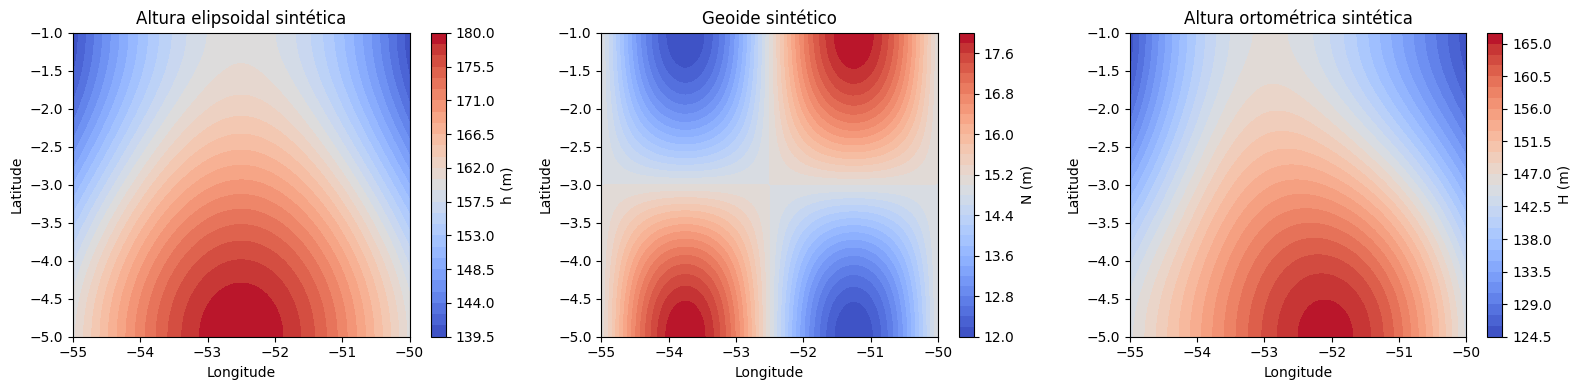

In [9]:
# ============================================================
# 7. MAPA SINTÉTICO DE h, N E H
# ============================================================

lon = np.linspace(-55, -50, 100)
lat = np.linspace(-5, -1, 80)
LON, LAT = np.meshgrid(lon, lat)

h_grid = 150 + 20*np.sin((LON+55)*np.pi/5) + 10*np.cos((LAT+5)*np.pi/4)
N_grid = 15 + 3*np.sin((LON+55)*2*np.pi/5) * np.cos((LAT+5)*np.pi/4)
H_grid = heights.ellipsoidal_to_orthometric_height(h_grid, N_grid)

plt.figure(figsize=(16, 4))

plt.subplot(1, 3, 1)
c1 = plt.contourf(LON, LAT, h_grid, cmap="coolwarm", levels=30)
plt.colorbar(c1, label="h (m)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Altura elipsoidal sintética")

plt.subplot(1, 3, 2)
c2 = plt.contourf(LON, LAT, N_grid, cmap="coolwarm", levels=30)
plt.colorbar(c2, label="N (m)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geoide sintético")

plt.subplot(1, 3, 3)
c3 = plt.contourf(LON, LAT, H_grid, cmap="coolwarm", levels=30)
plt.colorbar(c3, label="H (m)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Altura ortométrica sintética")

plt.tight_layout()
plt.show()


## 8. Comparação com funções equivalentes do módulo `geoid.py`


In [10]:
# ============================================================
# 8. COMPARAÇÃO COM geodesy/geoid.py
# ============================================================

H_from_geoid_module = geoid.ellipsoidal_to_orthometric(h, N)
h_from_geoid_module = geoid.orthometric_to_ellipsoidal(H_from_geoid_module, N)

print("Diferença entre heights e geoid para H:")
print(np.max(np.abs(H_from_geoid_module - H)))

print("Erro de retorno pelo módulo geoid:")
print(np.max(np.abs(h_from_geoid_module - h)))


Diferença entre heights e geoid para H:
0.0
Erro de retorno pelo módulo geoid:
1.4210854715202004e-14


## 9. Relação entre número geopotencial e latitude


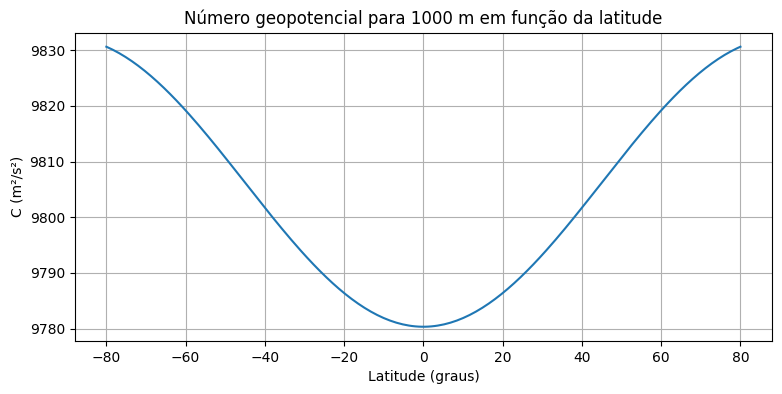

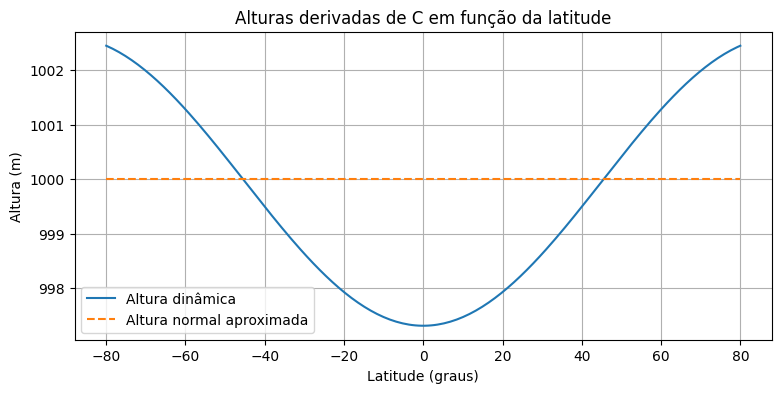

In [11]:
# ============================================================
# 9. C, GRAVIDADE NORMAL E ALTURA APROXIMADA
# ============================================================

latitudes = np.linspace(-80, 80, 200)
gamma_lat = normal_gravity.normal_gravity_somigliana(latitudes)

# Número geopotencial equivalente a aproximadamente 1000 m
C_lat = gamma_lat * 1000.0

H_dyn_lat = heights.dynamic_height(C_lat)
H_norm_lat = heights.normal_height(C_lat, mean_normal_gravity=gamma_lat)

plt.figure(figsize=(9, 4))
plt.plot(latitudes, C_lat)
plt.xlabel("Latitude (graus)")
plt.ylabel("C (m²/s²)")
plt.title("Número geopotencial para 1000 m em função da latitude")
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(latitudes, H_dyn_lat, label="Altura dinâmica")
plt.plot(latitudes, H_norm_lat, linestyle="--", label="Altura normal aproximada")
plt.xlabel("Latitude (graus)")
plt.ylabel("Altura (m)")
plt.title("Alturas derivadas de C em função da latitude")
plt.legend()
plt.grid(True)
plt.show()


## 10. Resumo final


Se todas as células foram executadas sem erro, o módulo `heights.py` está funcionando corretamente.

Os próximos notebooks podem testar:

```python
geodesy/anomalies.py
geodesy/geoid.py
```
